# Comparação de Tamanho de Imagem — GTSRB
Experimento opcional 6.2 — comparação das 5 arquiteturas do grupo (Baseline, BN, VGG-like, ResNet-18, Mesclagem) em dois tamanhos de imagem diferentes (48x48 e 64x64)

In [1]:
!pip install -q torch torchvision seaborn

### 1. SETUP

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import copy
import time
import json
from typing import Optional

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions


In [3]:
model_pth_path = '/content/models_pth'
os.makedirs(model_pth_path, exist_ok=True)
os.makedirs("figuras", exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Hiperparâmetros

In [4]:
IMG_SIZES = [48, 64]     # os dois tamanhos a comparar
BATCH_SIZE = 128
NUM_EPOCHS = 15          # reduzido por causa da escala (5 arquiteturas x 2 tamanhos = 10 treinos)
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


In [5]:
def get_loaders_for_size(img_size):
    """Carrega train/val/test loaders para um tamanho de imagem especifico."""
    return get_dataloaders(img_size=img_size, batch_size=BATCH_SIZE)

# Sanity check rapido nos dois tamanhos
for size in IMG_SIZES:
    tl, vl, _ = get_loaders_for_size(size)
    x, y = next(iter(tl))
    print(f"img_size={size}: {len(tl)} batches de treino | shape de um batch: {x.shape}")


100%|██████████| 187M/187M [00:25<00:00, 7.31MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.05MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 186kB/s]


img_size=48: 167 batches de treino | shape de um batch: torch.Size([128, 3, 48, 48])
img_size=64: 167 batches de treino | shape de um batch: torch.Size([128, 3, 64, 64])


### 3. Arquiteturas (as 5 do grupo)

#### 3.1 Baseline (EHMNet)

In [6]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x); x = torch.relu(x); x = self.pool1(x)
        x = self.conv2(x); x = torch.relu(x); x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x); x = torch.relu(x)
        x = self.fc2(x)
        return x


#### 3.2 Baseline com BatchNorm (EHMNet_BN)

In [7]:
class EHMNet_BN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet_BN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x); x = self.bn1(x); x = torch.relu(x); x = self.pool1(x)
        x = self.conv2(x); x = self.bn2(x); x = torch.relu(x); x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x); x = torch.relu(x)
        x = self.fc2(x)
        return x


#### 3.3 VGG-like (SmallVGGNet)

In [8]:
class SmallVGGNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(SmallVGGNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding='same')
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding='same')
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(0.5)
        spatial = img_size // 8
        self.fc1 = nn.Linear(spatial * spatial * 128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn5(self.conv5(x)))
        x = torch.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


#### 3.4 Bloco residual compartilhado (usado pela ResNet-18 e pela Mesclagem)

In [9]:
class BasicBlock(nn.Module):
    """Bloco residual: dois convs 3x3 + BatchNorm, com conexao de atalho (skip connection)."""
    expansion: int = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: Optional[nn.Module] = None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


#### 3.5 ResNet-18 adaptada

In [10]:
class ResNet18(nn.Module):
    """ResNet-18 adaptada para imagens pequenas (sem o maxpool/stride-2 iniciais da versao original).
    Usa AdaptiveAvgPool2d, por isso funciona com qualquer img_size sem precisar mudar a FC."""
    def __init__(self, num_classes: int = 43, img_size: int = 32) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)
        self._init_weights()

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = [BasicBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


#### 3.6 Arquitetura Própria (Mesclagem)

In [11]:
class EHMNet_Mesclagem(nn.Module):
    """Combina blocos residuais (ResNet) + 2 convs por bloco com BN (VGG-like) + GAP + Dropout.
    Tambem usa AdaptiveAvgPool2d, entao funciona com qualquer img_size."""
    def __init__(self, num_classes: int = 43, img_size: int = 32, dropout: float = 0.5):
        super().__init__()
        self.stem_conv = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.stem_bn = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.stage1 = self._make_stage(32, 32, stride=1)
        self.stage2 = self._make_stage(32, 64, stride=2)
        self.stage3 = self._make_stage(64, 128, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    @staticmethod
    def _make_stage(in_channels, out_channels, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        return BasicBlock(in_channels, out_channels, stride, downsample)

    def forward(self, x):
        x = self.relu(self.stem_bn(self.stem_conv(x)))
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


ARCHITECTURES = {
    "baseline": EHMNet,
    "bn": EHMNet_BN,
    "vgg": SmallVGGNet,
    "resnet18": ResNet18,
    "mesclagem": EHMNet_Mesclagem,
}
ARCH_LABELS = {
    "baseline": "Baseline (EHMNet)",
    "bn": "Baseline + BN",
    "vgg": "VGG-like",
    "resnet18": "ResNet-18",
    "mesclagem": "Mesclagem",
}


### 4. Funções para Cálculo e Comparação das Métricas

In [12]:
def train_one_epoch(trainloader, model, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total


def validate(val_loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss/total, correct/total


def predict(loader, model, device):
    model.eval()
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)
    return np.concatenate(ytrue), np.concatenate(ypred)


def per_class_accuracy(y_true, y_pred, num_classes=NUM_CLASSES):
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        accs[c] = float((y_pred[mask] == c).sum()) / total if total > 0 else float('nan')
    return accs


def save_model_state(state_dict, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(state_dict, PATH)
    return PATH


### 5. Função de treino completo (genérica para qualquer arquitetura/tamanho)

In [13]:
def run_experiment(model_class, model_name, train_loader, val_loader, num_epochs, lr, device, img_size):
    model = model_class(num_classes=NUM_CLASSES, img_size=img_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    t0 = time.time()
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())  # copia: senao guarda referencia e vira o peso da ultima epoca

        if epoch % 3 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    train_time_sec = time.time() - t0
    checkpoint_path = save_model_state(best_state, f"{model_name}.pt")

    best_model = model_class(num_classes=NUM_CLASSES, img_size=img_size).to(device)
    best_model.load_state_dict(best_state)
    best_model.eval()

    n_params = count_params(best_model)
    print(f"-> Melhor val acc: {best_val_acc:.4f} (epoca {best_epoch}) | {n_params:,} parametros | {train_time_sec:.1f}s\n")

    return {
        "name": model_name,
        "model": best_model,
        "history": history,
        "checkpoint_path": checkpoint_path,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "n_params": n_params,
        "train_time_sec": train_time_sec,
        "img_size": img_size,
    }


### 6. Treinando as 5 arquiteturas nos 2 tamanhos de imagem (10 treinos)

In [14]:
all_results = {}  # all_results[img_size][arch_name] = resultado

for size in IMG_SIZES:
    print(f"\n{'#'*70}\n# TAMANHO DE IMAGEM: {size}x{size}\n{'#'*70}\n")
    train_loader, val_loader, test_loader = get_loaders_for_size(size)
    all_results[size] = {}

    for arch_name, model_class in ARCHITECTURES.items():
        print(f"--- Treinando {ARCH_LABELS[arch_name]} (img_size={size}) ---")
        res = run_experiment(
            model_class, f"{arch_name}_{size}",
            train_loader, val_loader, NUM_EPOCHS, LR, device, img_size=size
        )
        res["test_loader"] = test_loader  # guarda referencia para avaliar depois
        all_results[size][arch_name] = res



######################################################################
# TAMANHO DE IMAGEM: 48x48
######################################################################

--- Treinando Baseline (EHMNet) (img_size=48) ---
[baseline_48] Epoch 01/15 | Train Acc: 0.6679 | Val Acc: 0.9135
[baseline_48] Epoch 03/15 | Train Acc: 0.9835 | Val Acc: 0.9690
[baseline_48] Epoch 06/15 | Train Acc: 0.9934 | Val Acc: 0.9919
[baseline_48] Epoch 09/15 | Train Acc: 0.9962 | Val Acc: 0.9936
[baseline_48] Epoch 12/15 | Train Acc: 0.9996 | Val Acc: 0.9942
[baseline_48] Epoch 15/15 | Train Acc: 1.0000 | Val Acc: 0.9949
-> Melhor val acc: 0.9953 (epoca 14) | 2,389,995 parametros | 179.8s

--- Treinando Baseline + BN (img_size=48) ---
[bn_48] Epoch 01/15 | Train Acc: 0.5663 | Val Acc: 0.8752
[bn_48] Epoch 03/15 | Train Acc: 0.9775 | Val Acc: 0.9833
[bn_48] Epoch 06/15 | Train Acc: 0.9965 | Val Acc: 0.9801
[bn_48] Epoch 09/15 | Train Acc: 0.9835 | Val Acc: 0.9790
[bn_48] Epoch 12/15 | Train Acc: 0.9993 | Val A

# ANALISE DE RESULTADOS

### 1. Avaliação no conjunto de teste para todas as combinações

In [15]:
rows = []
for size in IMG_SIZES:
    for arch_name, res in all_results[size].items():
        test_loader = res["test_loader"]
        ytrue, ypred = predict(test_loader, res["model"], device)
        global_acc = float((ypred == ytrue).mean())
        macro_acc = float(per_class_accuracy(ytrue, ypred).mean())
        res["test_global_acc"] = global_acc
        res["test_macro_acc"] = macro_acc
        rows.append({
            "arquitetura": ARCH_LABELS[arch_name],
            "img_size": size,
            "n_params": res["n_params"],
            "tempo_treino_s": round(res["train_time_sec"], 1),
            "melhor_val_acc": round(res["best_val_acc"], 4),
            "acc_teste": round(global_acc, 4),
            "macro_acc_teste": round(macro_acc, 4),
        })

resumo_tamanhos = pd.DataFrame(rows)
print(resumo_tamanhos.to_string(index=False))


      arquitetura  img_size  n_params  tempo_treino_s  melhor_val_acc  acc_teste  macro_acc_teste
Baseline (EHMNet)        48   2389995           179.8          0.9953     0.9070           0.8674
    Baseline + BN        48   2390187           173.7          0.9946     0.9129           0.8679
         VGG-like        48   1478859           187.4          0.9977     0.9789           0.9698
        ResNet-18        48  11190891           656.9          0.9998     0.9837           0.9719
        Mesclagem        48    312907           204.1          0.9976     0.9652           0.9396
Baseline (EHMNet)        64   4225003           203.4          0.9910     0.8842           0.8350
    Baseline + BN        64   4225195           198.4          0.9932     0.9019           0.8528
         VGG-like        64   2396363           220.0          0.9977     0.9710           0.9563
        ResNet-18        64  11190891          1091.1          0.9998     0.9770           0.9586
        Mesclagem   

### 2. Acurácia de teste por arquitetura, nos dois tamanhos

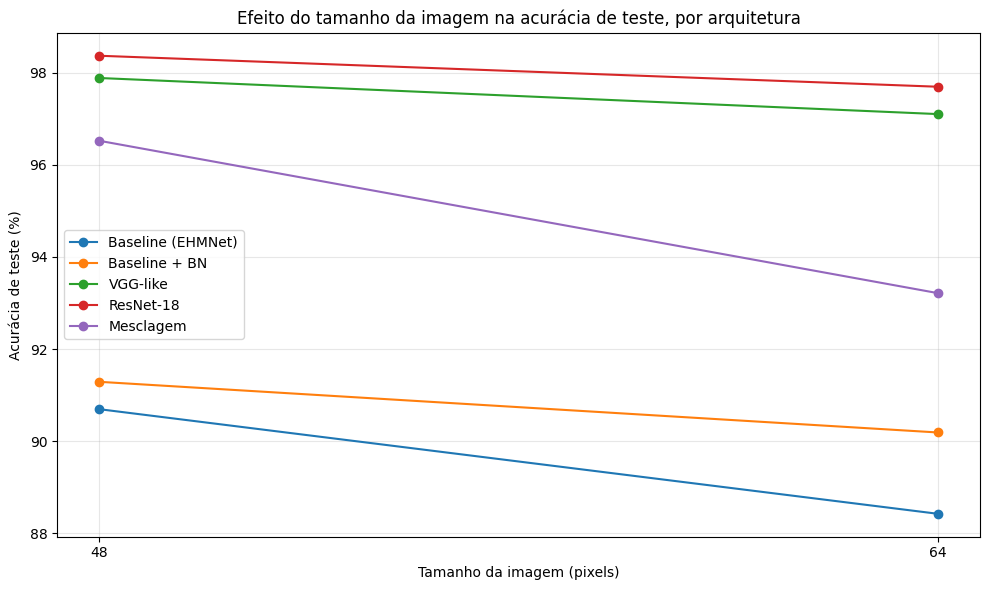

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for arch_name in ARCHITECTURES:
    accs = [all_results[size][arch_name]["test_global_acc"] * 100 for size in IMG_SIZES]
    ax.plot(IMG_SIZES, accs, marker="o", label=ARCH_LABELS[arch_name])

ax.set_xlabel("Tamanho da imagem (pixels)")
ax.set_ylabel("Acurácia de teste (%)")
ax.set_title("Efeito do tamanho da imagem na acurácia de teste, por arquitetura")
ax.set_xticks(IMG_SIZES)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/tamanho_imagem_acuracia.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Custo computacional: parâmetros e tempo de treino

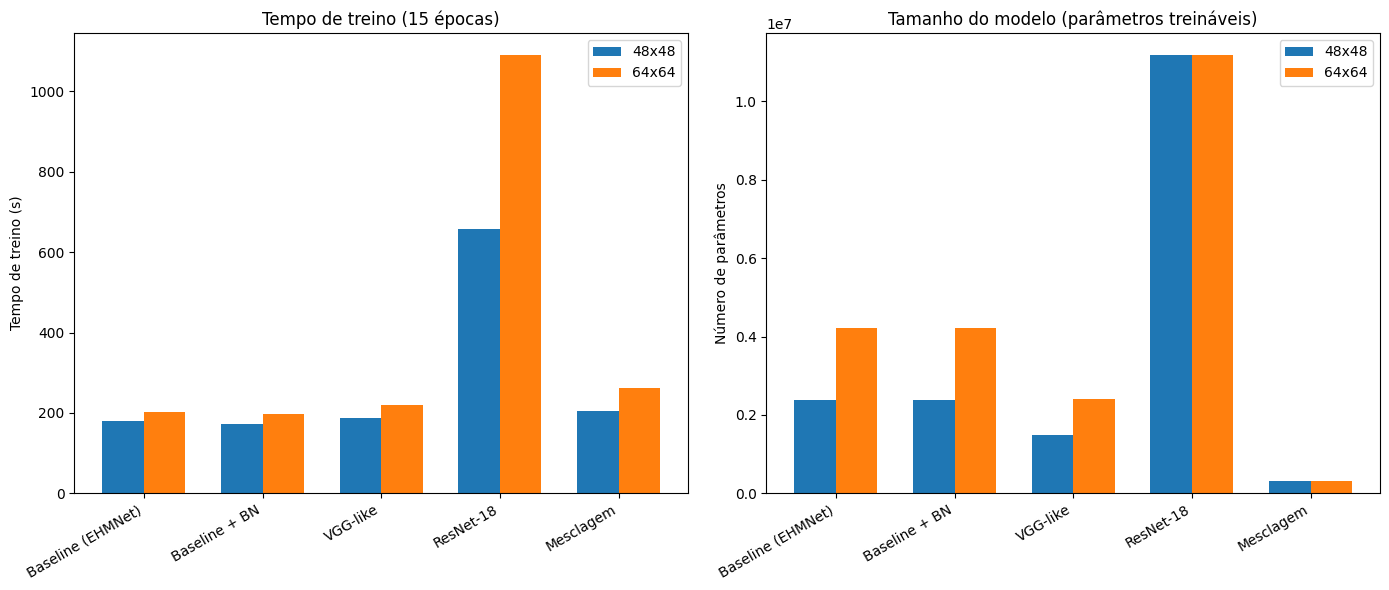

Nota: ResNet-18 e Mesclagem usam Global Average Pooling, por isso o numero de
parametros delas NAO muda com o tamanho da imagem -- so o custo de computacao
(tempo de treino) muda. Ja Baseline, BN e VGG usam Flatten + camada densa,
entao o numero de parametros cresce junto com o tamanho da imagem.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(ARCHITECTURES))
width = 0.35
for i, size in enumerate(IMG_SIZES):
    times = [all_results[size][a]["train_time_sec"] for a in ARCHITECTURES]
    axes[0].bar(x + (i - 0.5) * width, times, width, label=f"{size}x{size}")
axes[0].set_xticks(x)
axes[0].set_xticklabels([ARCH_LABELS[a] for a in ARCHITECTURES], rotation=30, ha="right")
axes[0].set_ylabel("Tempo de treino (s)")
axes[0].set_title(f"Tempo de treino ({NUM_EPOCHS} épocas)")
axes[0].legend()

for i, size in enumerate(IMG_SIZES):
    params = [all_results[size][a]["n_params"] for a in ARCHITECTURES]
    axes[1].bar(x + (i - 0.5) * width, params, width, label=f"{size}x{size}")
axes[1].set_xticks(x)
axes[1].set_xticklabels([ARCH_LABELS[a] for a in ARCHITECTURES], rotation=30, ha="right")
axes[1].set_ylabel("Número de parâmetros")
axes[1].set_title("Tamanho do modelo (parâmetros treináveis)")
axes[1].legend()

plt.tight_layout()
plt.savefig("figuras/tamanho_imagem_custo.png", dpi=150, bbox_inches="tight")
plt.show()

print("Nota: ResNet-18 e Mesclagem usam Global Average Pooling, por isso o numero de")
print("parametros delas NAO muda com o tamanho da imagem -- so o custo de computacao")
print("(tempo de treino) muda. Ja Baseline, BN e VGG usam Flatten + camada densa,")
print("entao o numero de parametros cresce junto com o tamanho da imagem.")


### 1.1 Curvas de treino (acurácia de validação por época, uma grade por arquitetura)

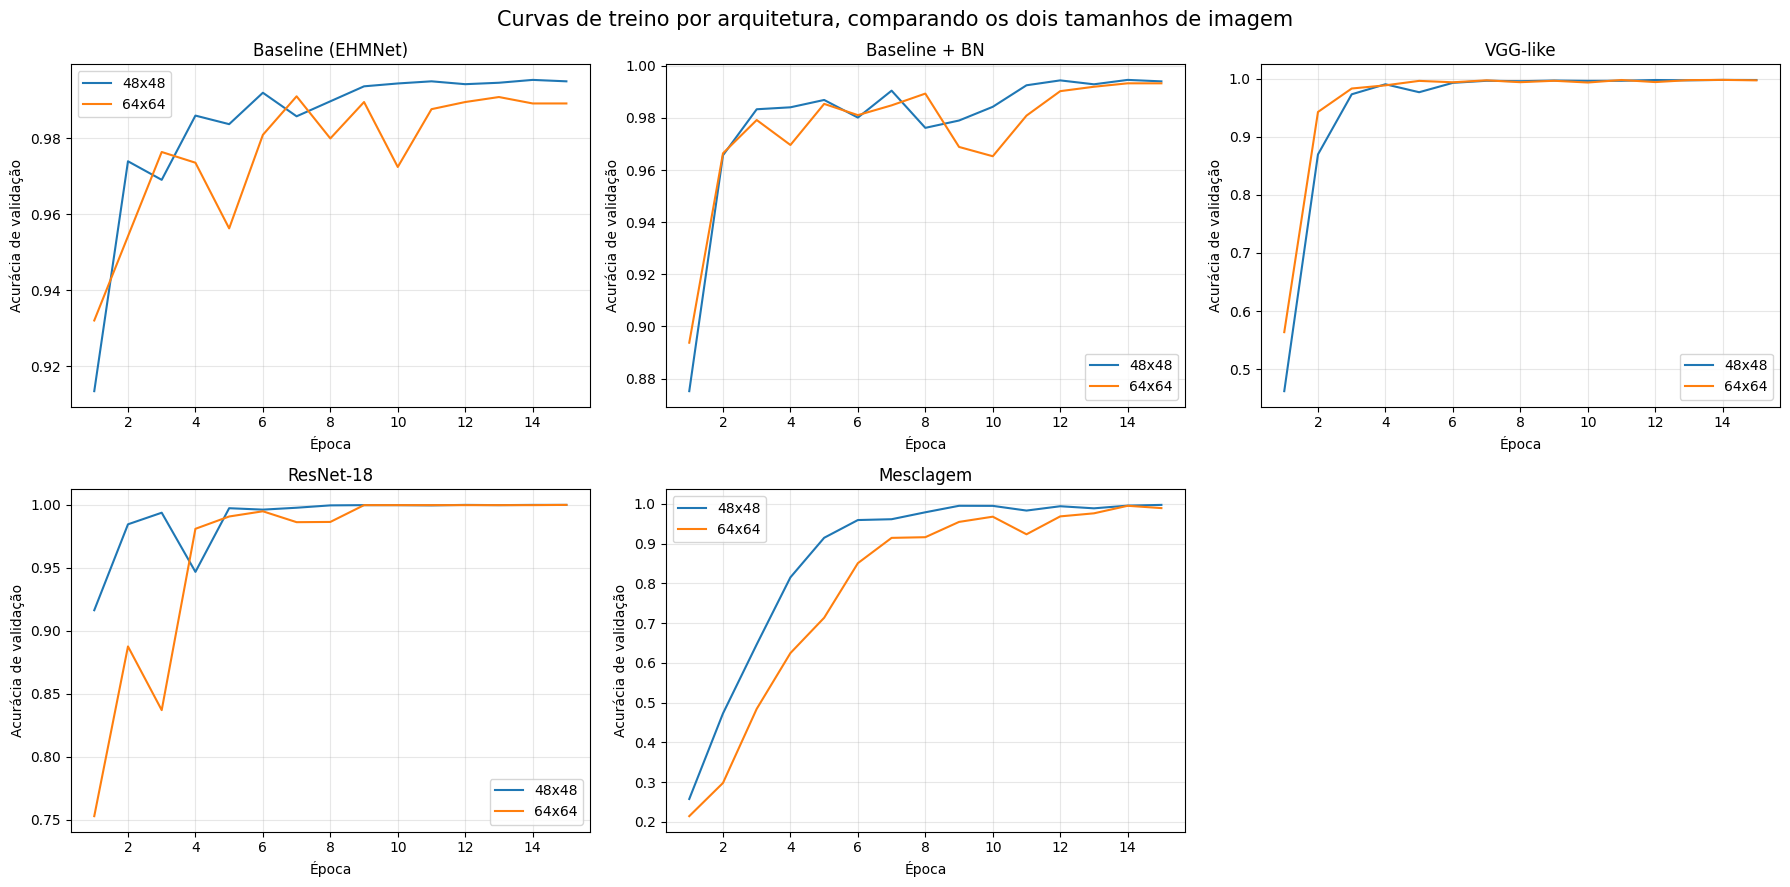

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

colors = {48: "tab:blue", 64: "tab:orange"}

for i, arch_name in enumerate(ARCHITECTURES):
    ax = axes[i]
    for size in IMG_SIZES:
        hist = all_results[size][arch_name]["history"]
        epochs = range(1, len(hist["val_acc"]) + 1)
        ax.plot(epochs, hist["val_acc"], label=f"{size}x{size}", color=colors[size])
    ax.set_title(ARCH_LABELS[arch_name])
    ax.set_xlabel("Época")
    ax.set_ylabel("Acurácia de validação")
    ax.legend()
    ax.grid(alpha=0.3)

# o grid tem 6 posicoes mas so 5 arquiteturas -- esconde o ultimo painel vazio
for j in range(len(ARCHITECTURES), len(axes)):
    axes[j].axis("off")

plt.suptitle("Curvas de treino por arquitetura, comparando os dois tamanhos de imagem", fontsize=15)
plt.tight_layout()
plt.savefig("figuras/tamanho_imagem_curvas_treino.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
import json as _json
from google.colab import drive
drive.mount('/content/drive')

drive_base = '/content/drive/MyDrive/trabalho-ia-gtsrb/comparacao_tamanho'
os.makedirs(drive_base, exist_ok=True)
os.makedirs(f'{drive_base}/models_pth', exist_ok=True)
resumo_path = f"{drive_base}/resumo_tamanhos.csv"
resumo_tamanhos.to_csv(resumo_path, index=False)
print(f"Tabela resumo salva em: {resumo_path}")

# Historico de cada treino (loss/acc por epoca), sem o objeto do modelo -- esse fica
# salvo separadamente em cada checkpoint .pt
historico_serializavel = {
    str(size): {
        arch_name: {
            "history": res["history"],
            "best_val_acc": res["best_val_acc"],
            "best_epoch": res["best_epoch"],
            "n_params": res["n_params"],
            "train_time_sec": res["train_time_sec"],
            "test_global_acc": res.get("test_global_acc"),
            "test_macro_acc": res.get("test_macro_acc"),
            "checkpoint_path": res["checkpoint_path"],
        }
        for arch_name, res in all_results[size].items()
    }
    for size in IMG_SIZES
}

historico_path = "/historico_completo.json"
with open(historico_path, "w") as f:
    _json.dump(historico_serializavel, f, indent=2)
print(f"Histórico completo salvo em: {historico_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tabela resumo salva em: /content/drive/MyDrive/trabalho-ia-gtsrb/comparacao_tamanho/resumo_tamanhos.csv
Histórico completo salvo em: /historico_completo.json
